In [1]:
#!/usr/bin/env python
import os
import sys
import time
import torch
import dill
import numpy as np
import collections
import imageio
import cv2

# -------------------------------
# Deoxys and Franka Interface Imports
# -------------------------------
sys.path.append("/home/franka_deoxys/deoxys_control/deoxys")
from deoxys import config_root
from deoxys.franka_interface import FrankaInterface
from deoxys.utils import YamlConfig
from deoxys.utils.config_utils import robot_config_parse_args
from deoxys.utils.input_utils import input2action
from deoxys.utils.io_devices import SpaceMouse
from deoxys.utils.log_utils import get_deoxys_example_logger
from deoxys.experimental.motion_utils import follow_joint_traj, reset_joints_to

sys.path.append("/home/franka_deoxys/deoxys_vision")
from deoxys_vision.networking.camera_redis_interface import CameraRedisSubInterface
from deoxys_vision.utils.camera_utils import assert_camera_ref_convention, get_camera_info



from util_eval import RobotStateRawObsDictGenerator, FrameStackForTrans

import math 

# -------------------------------
# Set device
# -------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

pybullet build time: Sep 21 2024 19:35:50


Using device: cuda


In [2]:
args = robot_config_parse_args()
print("Using config:", args.interface_cfg)

Using config: charmander.yml


In [3]:
# -------------------------------
# Load Robot and Controller Configurations
# -------------------------------

robot_interface = FrankaInterface(os.path.join(config_root, args.interface_cfg))
controller_cfg = YamlConfig(os.path.join(config_root, args.controller_cfg)).as_easydict()
controller_type = args.controller_type
print("Using controller type:", controller_type)

# Initialize SpaceMouse (if used)
# # For wireless or different devices, adjust vendor/product ids.
# spacemouse = SpaceMouse(vendor_id=9583, product_id=50770)
# spacemouse.start_control()

# (Assume that RobotStateRawObsDictGenerator is available in your environment)
# For example:
# from deoxys.raw_obs_generator import RobotStateRawObsDictGenerator
raw_obs_dict_generator = RobotStateRawObsDictGenerator()

def set_gripper(open=True):
    d = -1.0 if open else 1.0
    action_close = np.array([0., 0., 0., 0., 0., 0., d])
    robot_interface.control(
        controller_type=controller_type,
        action=action_close,
        controller_cfg=controller_cfg,
    )

Using controller type: OSC_POSE


In [4]:
# -------------------------------
# Setup Camera Interfaces
# -------------------------------
camera_ids = [0, 1]
cr_interfaces = {}
use_depth = False

for camera_id in camera_ids:
    camera_ref = f"rs_{camera_id}"
    assert_camera_ref_convention(camera_ref)
    camera_info = get_camera_info(camera_ref)
    # print("Camera Info for {}:".format(camera_ref), camera_info)
    cr_interface = CameraRedisSubInterface(camera_info=camera_info, use_depth=use_depth, redis_host='127.0.0.1')
    cr_interface.start()
    cr_interfaces[camera_id] = cr_interface

def get_imgs(use_depth=False):
    data = {}
    for camera_id in camera_ids:
        img_info = cr_interfaces[camera_id].get_img_info()
        data[f"camera_{camera_id}"] = img_info

        imgs = cr_interfaces[camera_id].get_img()
        color_img = imgs["color"][..., ::-1]  # Convert from BGR to RGB if needed.
        color_img = cv2.resize(color_img, (320, 240))
        data[f"camera_{camera_id}_color"] = color_img

        if use_depth:
            depth_img = imgs["depth"]
            depth_img = cv2.resize(depth_img, (224, 224))
            data[f"camera_{camera_id}_depth"] = depth_img
    return data

def get_current_obs():
    """
    Gather the latest robot state and images to form an observation dictionary.
    The raw state is obtained from the deoxys robot interface, while images come from the camera interfaces.
    """
    last_state = robot_interface._state_buffer[-1]
    last_gripper_state = robot_interface._gripper_state_buffer[-1]
    # print(last_state,last_gripper_state)
    obs_dict = raw_obs_dict_generator.get_raw_obs_dict({
        "last_state": last_state,
        "last_gripper_state": last_gripper_state
    })
    data = get_imgs(use_depth=False)
    # Map your camera images to the keys expected by the diffusion policy.
    # Here, we assume:
    #   agentview_image  <- wrist camera image from camera_0_color
    #   robot0_eye_in_hand_image  <- front camera image from camera_1_color
    agentview_img = data['camera_0_color']
    eye_in_hand_img = data['camera_1_color']
    # Transpose images to channel-first if required.
    obs_dict['agentview_rgb'] = agentview_img.transpose(2, 0, 1).astype(np.float32) / 255.0
    obs_dict['eye_in_hand_rgb'] = eye_in_hand_img.transpose(2, 0, 1).astype(np.float32) / 255.0
    return obs_dict

# -------------------------------
# Helper Classes
# -------------------------------
class FrameStackForTrans:
    def __init__(self, num_frames):
        self.num_frames = num_frames
        self.obs_history = {}

    def reset(self, init_obs):
        self.obs_history = {}
        for k in init_obs:
            self.obs_history[k] = collections.deque([init_obs[k][None] for _ in range(self.num_frames)], maxlen=self.num_frames)
        return {k: np.concatenate(self.obs_history[k], axis=0) for k in self.obs_history}

    def add_new_obs(self, new_obs):
        for k in new_obs:
            if 'timesteps' in k or 'actions' in k:
                continue
            self.obs_history[k].append(new_obs[k][None])
        return {k: np.concatenate(self.obs_history[k], axis=0) for k in self.obs_history}

def undo_transform_action(action, rotation_transformer):
    # This mirrors your simulation code logic.
    raw_shape = action.shape
    if raw_shape[-1] == 20:
        action = action.reshape(-1, 2, 10)
    d_rot = action.shape[-1] - 4
    pos = action[..., :3]
    rot = action[..., 3:3+d_rot]
    gripper = action[..., -1:]
    rot = rotation_transformer.inverse(rot)
    uaction = np.concatenate([pos, rot, gripper], axis=-1)
    if raw_shape[-1] == 20:
        uaction = uaction.reshape(*raw_shape[:-1], 14)
    return uaction

CameraRedisSubInterface:: {'camera_id': 0, 'camera_type': 'rs', 'camera_name': 'camera_rs_0'} True False
CameraRedisSubInterface:: {'camera_id': 1, 'camera_type': 'rs', 'camera_name': 'camera_rs_1'} True False


In [5]:
data = get_imgs()
img_wrist = data['camera_0_color']
img_front = data['camera_1_color']

agentview_rgb=img_wrist 
eye_in_hand_rgb=img_front

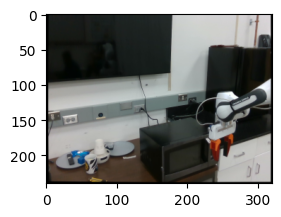

In [6]:
import matplotlib.pyplot as plt
plt.subplot(121)
plt.imshow(agentview_rgb[:,:,::-1])

In [7]:
obs = get_current_obs()
obs.keys()

dict_keys(['ee_states', 'joint_states', 'gripper_states', 'agentview_rgb', 'eye_in_hand_rgb'])

In [8]:
obs['gripper_states'][0]

0.07860168814659119

In [9]:
# observation/state: (8,) float32
# observation/image: (256, 256, 3) float32
# observation/wrist_image: (256, 256, 3) float32
# key prompt data= pick up the coffee pod

In [10]:
# https://github.com/ARISE-Initiative/robosuite/blob/eafb81f54ffc104f905ee48a16bb15f059176ad3/robosuite/utils/transform_utils.py

def mat2quat(rmat):
    """
    Converts given rotation matrix to quaternion.

    Args:
        rmat (np.array): 3x3 rotation matrix

    Returns:
        np.array: (x,y,z,w) float quaternion angles
    """
    M = np.asarray(rmat).astype(np.float32)[:3, :3]

    m00 = M[0, 0]
    m01 = M[0, 1]
    m02 = M[0, 2]
    m10 = M[1, 0]
    m11 = M[1, 1]
    m12 = M[1, 2]
    m20 = M[2, 0]
    m21 = M[2, 1]
    m22 = M[2, 2]
    # symmetric matrix K
    K = np.array(
        [
            [m00 - m11 - m22, np.float32(0.0), np.float32(0.0), np.float32(0.0)],
            [m01 + m10, m11 - m00 - m22, np.float32(0.0), np.float32(0.0)],
            [m02 + m20, m12 + m21, m22 - m00 - m11, np.float32(0.0)],
            [m21 - m12, m02 - m20, m10 - m01, m00 + m11 + m22],
        ]
    )
    K /= 3.0
    # quaternion is Eigen vector of K that corresponds to largest eigenvalue
    w, V = np.linalg.eigh(K)
    inds = np.array([3, 0, 1, 2])
    q1 = V[inds, np.argmax(w)]
    if q1[0] < 0.0:
        np.negative(q1, q1)
    inds = np.array([1, 2, 3, 0])
    return q1[inds]
    
def mat2pose(hmat):
    """
    Converts a homogeneous 4x4 matrix into pose.

    Args:
        hmat (np.array): a 4x4 homogeneous matrix

    Returns:
        2-tuple:

            - (np.array) (x,y,z) position array in cartesian coordinates
            - (np.array) (x,y,z,w) orientation array in quaternion form
    """
    pos = hmat[:3, 3]
    orn = mat2quat(hmat[:3, :3])
    return pos, orn
    
def mat4(array):
    """
    Converts an array to 4x4 matrix.

    Args:
        array (n-array): the array in form of vec, list, or tuple

    Returns:
        np.array: a 4x4 numpy matrix
    """
    return np.array(array, dtype=np.float32).reshape((4, 4))


def quat2axisangle(quat):
    """
    Converts quaternion to axis-angle format.
    Returns a unit vector direction scaled by its angle in radians.

    Args:
        quat (np.array): (x,y,z,w) vec4 float angles

    Returns:
        np.array: (ax,ay,az) axis-angle exponential coordinates
    """
    # clip quaternion
    if quat[3] > 1.0:
        quat[3] = 1.0
    elif quat[3] < -1.0:
        quat[3] = -1.0

    den = np.sqrt(1.0 - quat[3] * quat[3])
    if math.isclose(den, 0.0):
        # This is (close to) a zero degree rotation, immediately return
        return np.zeros(3)

    return (quat[:3] * 2.0 * math.acos(quat[3])) / den

In [11]:
def franka_ee_states_to_pos_quat(ee_states): 
    T_all = np.array([mat4(ee_states[i]) for i in range(ee_states.shape[0])])  # (N, 4, 4)
    pos_all=[]
    ori_all=[]
    for i in range(T_all.shape[0]):
        pos, orn = mat2pose(T_all[i])
        pos_all.append(pos)
        ori_all.append(orn)
    pos_all = np.array(pos_all)
    quat_all = np.array(ori_all)
    return pos_all, quat_all

 

In [12]:
def deoxys_obs_to_libero_obs(obs): 
    ee_states = obs['ee_states']
    img = obs['agentview_rgb']
    img_wrist = obs['eye_in_hand_rgb']
    prompt = "pick up the coffee pod"
    gripper_states1 = obs['gripper_states'][0]

    gripper_states = np.array([gripper_states1, gripper_states1])
    pos_all, quat_all = franka_ee_states_to_pos_quat(ee_states.reshape(1, 16)) 
    rpy_all = np.array([quat2axisangle(quat_all[i]) for i in range(quat_all.shape[0])]) 
    ee_states = np.hstack([pos_all, rpy_all] )[0]
    states = np.hstack([ee_states, gripper_states])

    # convert images to 256x256
    img = np.array([cv2.resize(img[i], (256,256)) for i in range(img.shape[0])])
    img_wrist = np.array([cv2.resize(img_wrist[i], (256,256)) for i in range(img_wrist.shape[0])])

    obs={
            "observation/state": states,
            "observation/image": img.transpose(1,2,0),
            "observation/wrist_image": img_wrist.transpose(1,2,0),
            "prompt": prompt,
        }
    return obs 

In [13]:
obs = get_current_obs()
obs = deoxys_obs_to_libero_obs(obs)

In [14]:
for key in obs.keys():
  if 'prompt' in key or 'text' in key:
    print('key', key, 'data=', obs[key])
    continue
  print(f"{key}: {obs[key].shape} {obs[key].dtype}")

observation/state: (8,) float64
observation/image: (256, 256, 3) float32
observation/wrist_image: (256, 256, 3) float32
key prompt data= pick up the coffee pod


### connect server

In [15]:
from openpi_client import websocket_client_policy as _websocket_client_policy

In [16]:
import dataclasses

@dataclasses.dataclass
class Args:
    #################################################################################################################
    # Model server parameters
    #################################################################################################################
    host: str = "192.168.1.47"
    port: int = 8000
    resize_size: int = 224
    replan_steps: int = 5

    #################################################################################################################
    # LIBERO environment-specific parameters
    #################################################################################################################
    task_suite_name: str = (
        "libero_90"  # Task suite. Options: libero_spatial, libero_object, libero_goal, libero_10, libero_90
    )
    num_steps_wait: int = 10  # Number of steps to wait for objects to stabilize i n sim
    num_trials_per_task: int = 5   # Number of rollouts per task

    #################################################################################################################
    # Utils
    #################################################################################################################
    video_out_path: str = "data/libero/videos"  # Path to save videos

    seed: int = 7  # Random Seed (for reproducibility)

args= Args()

In [17]:
client = _websocket_client_policy.WebsocketClientPolicy(args.host, args.port)

In [18]:
action_chunk = client.infer(obs)["actions"]
action_chunk.shape

(10, 7)

In [34]:
# reset robot
reset_joint_positions = [-0.025, -0.392,  0.019, -2.436,  0.027,  1.964, 0.699]
set_gripper(open=True)
reset_joints_to(robot_interface, reset_joint_positions)
set_gripper(open=True)

JOINT_POSITION


In [20]:
action_to_execute = action_chunk[0]
action_to_execute.shape

(7,)

In [ ]:
# robot_interface.control(
#     controller_type=controller_type,
#     action=action_to_execute,
#     controller_cfg=controller_cfg,
# )

In [33]:
import collections
action_plan = collections.deque()
t = 0 

while t < 1000:
    try:  
        if not action_plan:
            # Finished executing previous action chunk -- compute new chunk
            # Prepare observations dict
            obs = get_current_obs()
            obs = deoxys_obs_to_libero_obs(obs)

            # Query model to get action
            action_chunk = client.infer(obs)["actions"]
            assert (
                len(action_chunk) >= args.replan_steps
            ), f"We want to replan every {args.replan_steps} steps, but policy only predicts {len(action_chunk)} steps."
            action_plan.extend(action_chunk[: args.replan_steps])

        action_to_execute = action_plan.popleft()

        robot_interface.control(
            controller_type=controller_type,
            action=action_to_execute,
            controller_cfg=controller_cfg,
        )
        

        t += 1

    except Exception as e: 
        print(e)
        break

KeyboardInterrupt: 